##Project Title:
###Lifestyle-Based Early Detection of Sleep Disorder Risk using Machine Learning

##Problem Statement
####Sleep disorders affect a significant portion of the global population and are closely linked to chronic health conditions such as cardiovascular disease, obesity, and mental health disorders. Traditional clinical diagnosis relies on expensive polysomnography (PSG) tests, making early intervention inaccessible for many.
####This project aims to build a machine learning classification system that predicts the risk level of sleep disorders — Healthy, Mild, Moderate, or Severe — purely from lifestyle and physiological features such as sleep duration, stress score, caffeine intake, physical activity, and chronotype.
####The objective is to enable proactive, non-invasive, and cost-effective early screening that can be deployed as a digital health tool, allowing individuals to assess their sleep disorder risk before seeking formal clinical evaluation.


###  Notebook Structure
| Section | Content |
|---|---|
| 1 | Imports & Setup |
| 2 | Data Loading & Preview |
| 3 | EDA — Figure 1 (Histogram), Figure 2 (Class Distribution), Figure 3 (Heatmap) |
| 4 | Data Preprocessing |
| 5 | Model Training (LR · RF · XGBoost · AdaBoost · CatBoost) |
| 6 | Evaluation & Results Table |
| 7 | Figure 4 — Confusion Matrix (Random Forest) |
| 8 | Figure 5 — Learning Curve (Random Forest) |
| 9 | Figure 6 — Feature Importance (Random Forest) |
| 10 | Sample Predictions |
| 11 | Model Comparison Bar Chart |
| 12 | Save Model & Quick Inference |
| 13 | Conclusion & Future Scope |

### Dataset credits : https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset [Mohan Krishna Thalla]

### Section 1 - Imports and Setup

In [10]:
%pip install xgboost catboost --quiet

In [11]:
#Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

#Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, learning_curve

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

#Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)

import joblib

print('All libraries imported successfully!')
print(f'  NumPy      : {np.__version__}')
print(f'  Pandas     : {pd.__version__}')
print(f'  Matplotlib : {matplotlib.__version__}')

All libraries imported successfully!
  NumPy      : 2.0.2
  Pandas     : 2.2.2
  Matplotlib : 3.10.0


### Section 2 - Data loading and preview

In [12]:
DATA_PATH = '/content/drive/MyDrive/AML/Mini-Project/Dataset/sleep_health_dataset.csv'
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Columns {len(df.columns)} : {list(df.columns)}")

Dataset shape: (100000, 32)
Columns 32 : ['person_id', 'age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested']


In [13]:
#Previewing dataset
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [14]:
#Getting info on datatypes and non-null counts
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


#### No null values exist and hence the task of handling missing values is eliminated

In [15]:
#Statistical summary of numerical features
df.describe().T.style.background_gradient(cmap='PuBu')

,count,mean,std,min,25%,50%,75%,max
person_id,100000.000000,50000.500000,28867.657797,1.000000,25000.750000,50000.500000,75000.250000,100000.000000
age,100000.000000,34.706870,11.036373,18.000000,26.000000,33.000000,42.000000,69.000000
bmi,100000.000000,26.289673,4.479578,16.000000,23.200000,26.300000,29.300000,45.000000
sleep_duration_hrs,100000.000000,6.423986,1.274627,3.000000,5.530000,6.360000,7.270000,10.500000
sleep_quality_score,100000.000000,4.871144,1.506517,1.000000,3.800000,4.900000,6.000000,10.000000
rem_percentage,100000.000000,20.243968,3.411354,10.000000,18.000000,20.300000,22.600000,30.000000
deep_sleep_percentage,100000.000000,20.253375,4.251096,5.000000,17.400000,20.300000,23.200000,30.000000
sleep_latency_mins,100000.000000,19.836810,7.584343,1.000000,14.000000,19.000000,25.000000,58.000000
wake_episodes_per_night,100000.000000,3.346610,1.920877,0.000000,2.000000,3.000000,5.000000,8.000000
caffeine_mg_before_bed,100000.000000,38.849500,69.395818,0.000000,0.000000,0.000000,80.000000,400.000000


In [16]:
vc = df['sleep_disorder_risk'].value_counts()
print("Target variable distribution: ")
print(vc)
print("\nPercentages")
print(vc.div(len(df)).mul(100).round(1).astype(str) + '%')
#The dataset is clearly imbalanced having majority alignment towards healthy samples

Target variable distribution: 
sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64

Percentages
sleep_disorder_risk
Healthy     54.2%
Mild        33.5%
Moderate     8.3%
Severe       4.1%
Name: count, dtype: object


### Section 3 - Exploratory Data Analysis

#### Figure 1 - Distribution of Sleep Duration

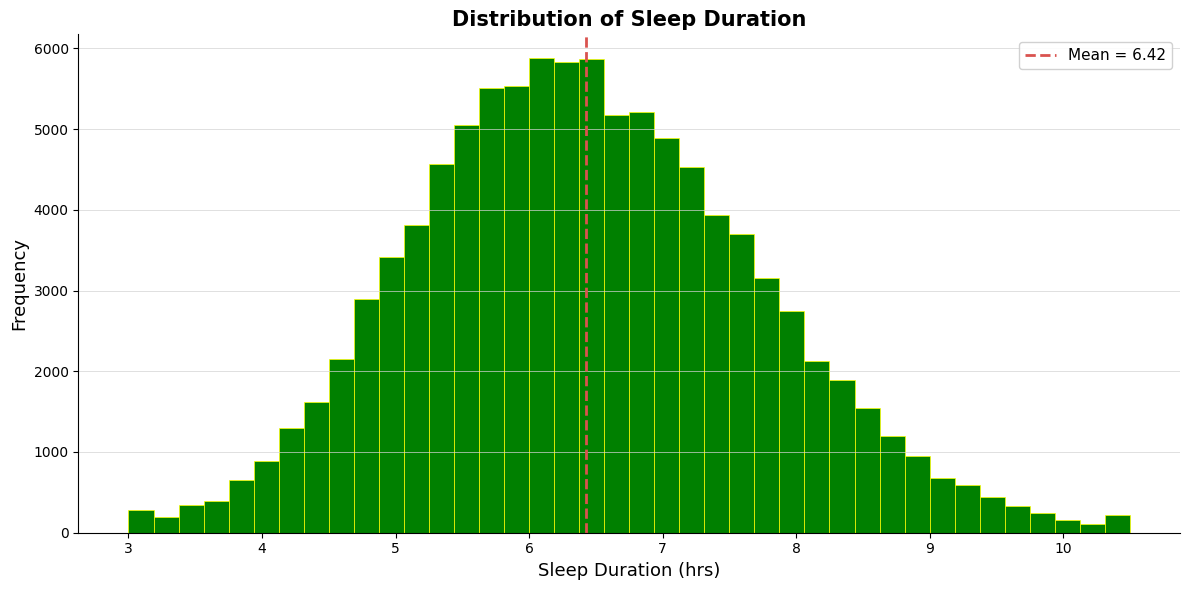

Mean sleep duration: 6.42 hrs

Observation: Sleep duration spans approximately 3-10.5 hrs with a mean of 6.42 hrs. The distribution is roughly bell-shaped with a slight left skew,
indicating a sub-population sleeping well below the recommended 7-9 hrs -- a key marker for sleep disorder risk.


In [17]:
mean_val = df['sleep_duration_hrs'].mean()

fig, ax = plt.subplots(figsize=(12,6), facecolor = 'white')

ax.hist(
    df['sleep_duration_hrs'],
    bins = 40,
    color = 'green',
    edgecolor = 'yellow',
    linewidth = 0.5
)
ax.axvline(
    mean_val,
    color = '#d9534f',
    linestyle = '--',
    linewidth = 2.0,
    label = f'Mean = {mean_val:.2f}'
)
ax.set_xlabel('Sleep Duration (hrs)', fontsize=13)
ax.set_ylabel('Frequency',fontsize=13)
ax.set_title('Distribution of Sleep Duration',fontsize = 15,fontweight='bold')
ax.legend(fontsize=11,framealpha=0.9)
ax.set_facecolor('white')
ax.grid(axis='y',color='lightgrey',linewidth=0.5,zorder=0)
for spine in ['top','right']:
  ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('hist_sleep_distribution.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print(f'Mean sleep duration: {mean_val:.2f} hrs')
print()
print('Observation: Sleep duration spans approximately 3-10.5 hrs with a mean of',
      f'{mean_val:.2f} hrs. The distribution is roughly bell-shaped with a slight left skew,')
print('indicating a sub-population sleeping well below the recommended 7-9 hrs --',
      'a key marker for sleep disorder risk.')

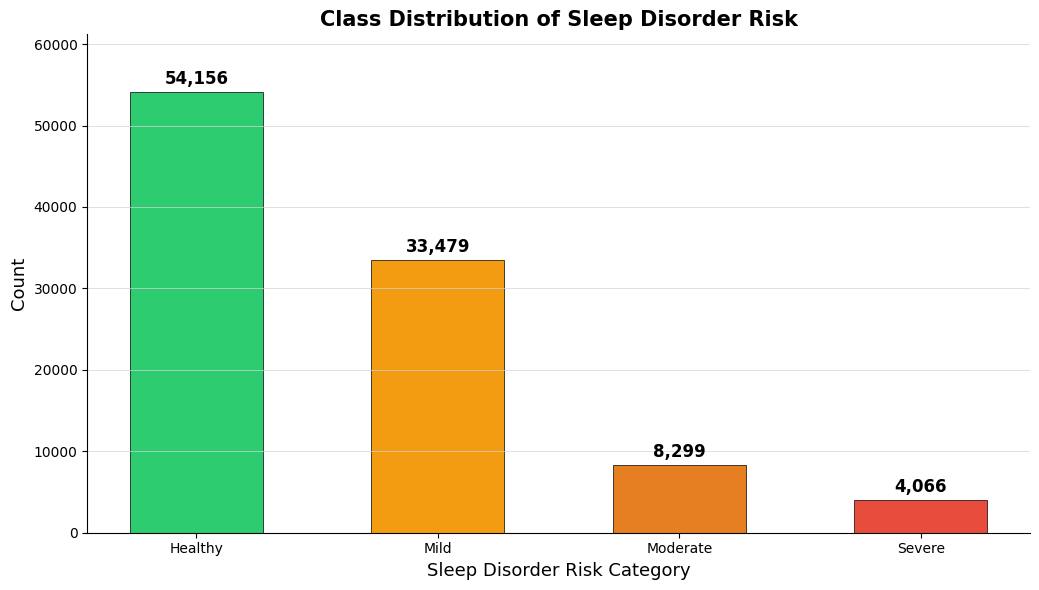

Observation: The dataset is imbalanced -- Healthy dominates at ~54% (54,156),
followed by Mild 33% (33,479), Moderate 8% (8,299), and Severe 4% (4,066).
Weighted evaluation metrics and ROC AUC are therefore prioritised over simple accuracy.


In [18]:
order = ['Healthy','Mild','Moderate','Severe']
color_map = {
    'Healthy': '#2ecc71',
    'Mild': '#f39c12',
    'Moderate': '#e67e22',
    'Severe': '#e74c3c'
}
counts = df['sleep_disorder_risk'].value_counts().reindex(order)

fig,ax = plt.subplots(figsize=(10.5,6), facecolor='white')

bars = ax.bar(
    counts.index,
    counts.values,
    color = [color_map[k] for k in counts.index],
    edgecolor = 'black',
    linewidth = 0.5,
    width = 0.55
)

#Count labels above each bar
for bar,val in zip(bars, counts.values):
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + 500,
      f'{val:,}',
      ha = 'center', va = 'bottom', fontsize = 12, fontweight = 'bold'
  )

ax.set_xlabel('Sleep Disorder Risk Category', fontsize = 13)
ax.set_ylabel('Count', fontsize = 13)
ax.set_title('Class Distribution of Sleep Disorder Risk', fontsize = 15, fontweight = 'bold')
ax.set_facecolor('white')
ax.grid(axis='y',color = 'lightgrey', linewidth = 0.5, zorder = 0)
ax.set_ylim(0, counts.max() * 1.13)
for spine in ['top','right']:
  ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('Class_distribution.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print('Observation: The dataset is imbalanced -- Healthy dominates at ~54% (54,156),')
print('followed by Mild 33% (33,479), Moderate 8% (8,299), and Severe 4% (4,066).')
print('Weighted evaluation metrics and ROC AUC are therefore prioritised over simple accuracy.')

####Figure 3 - Pearson Correlation Heatmap

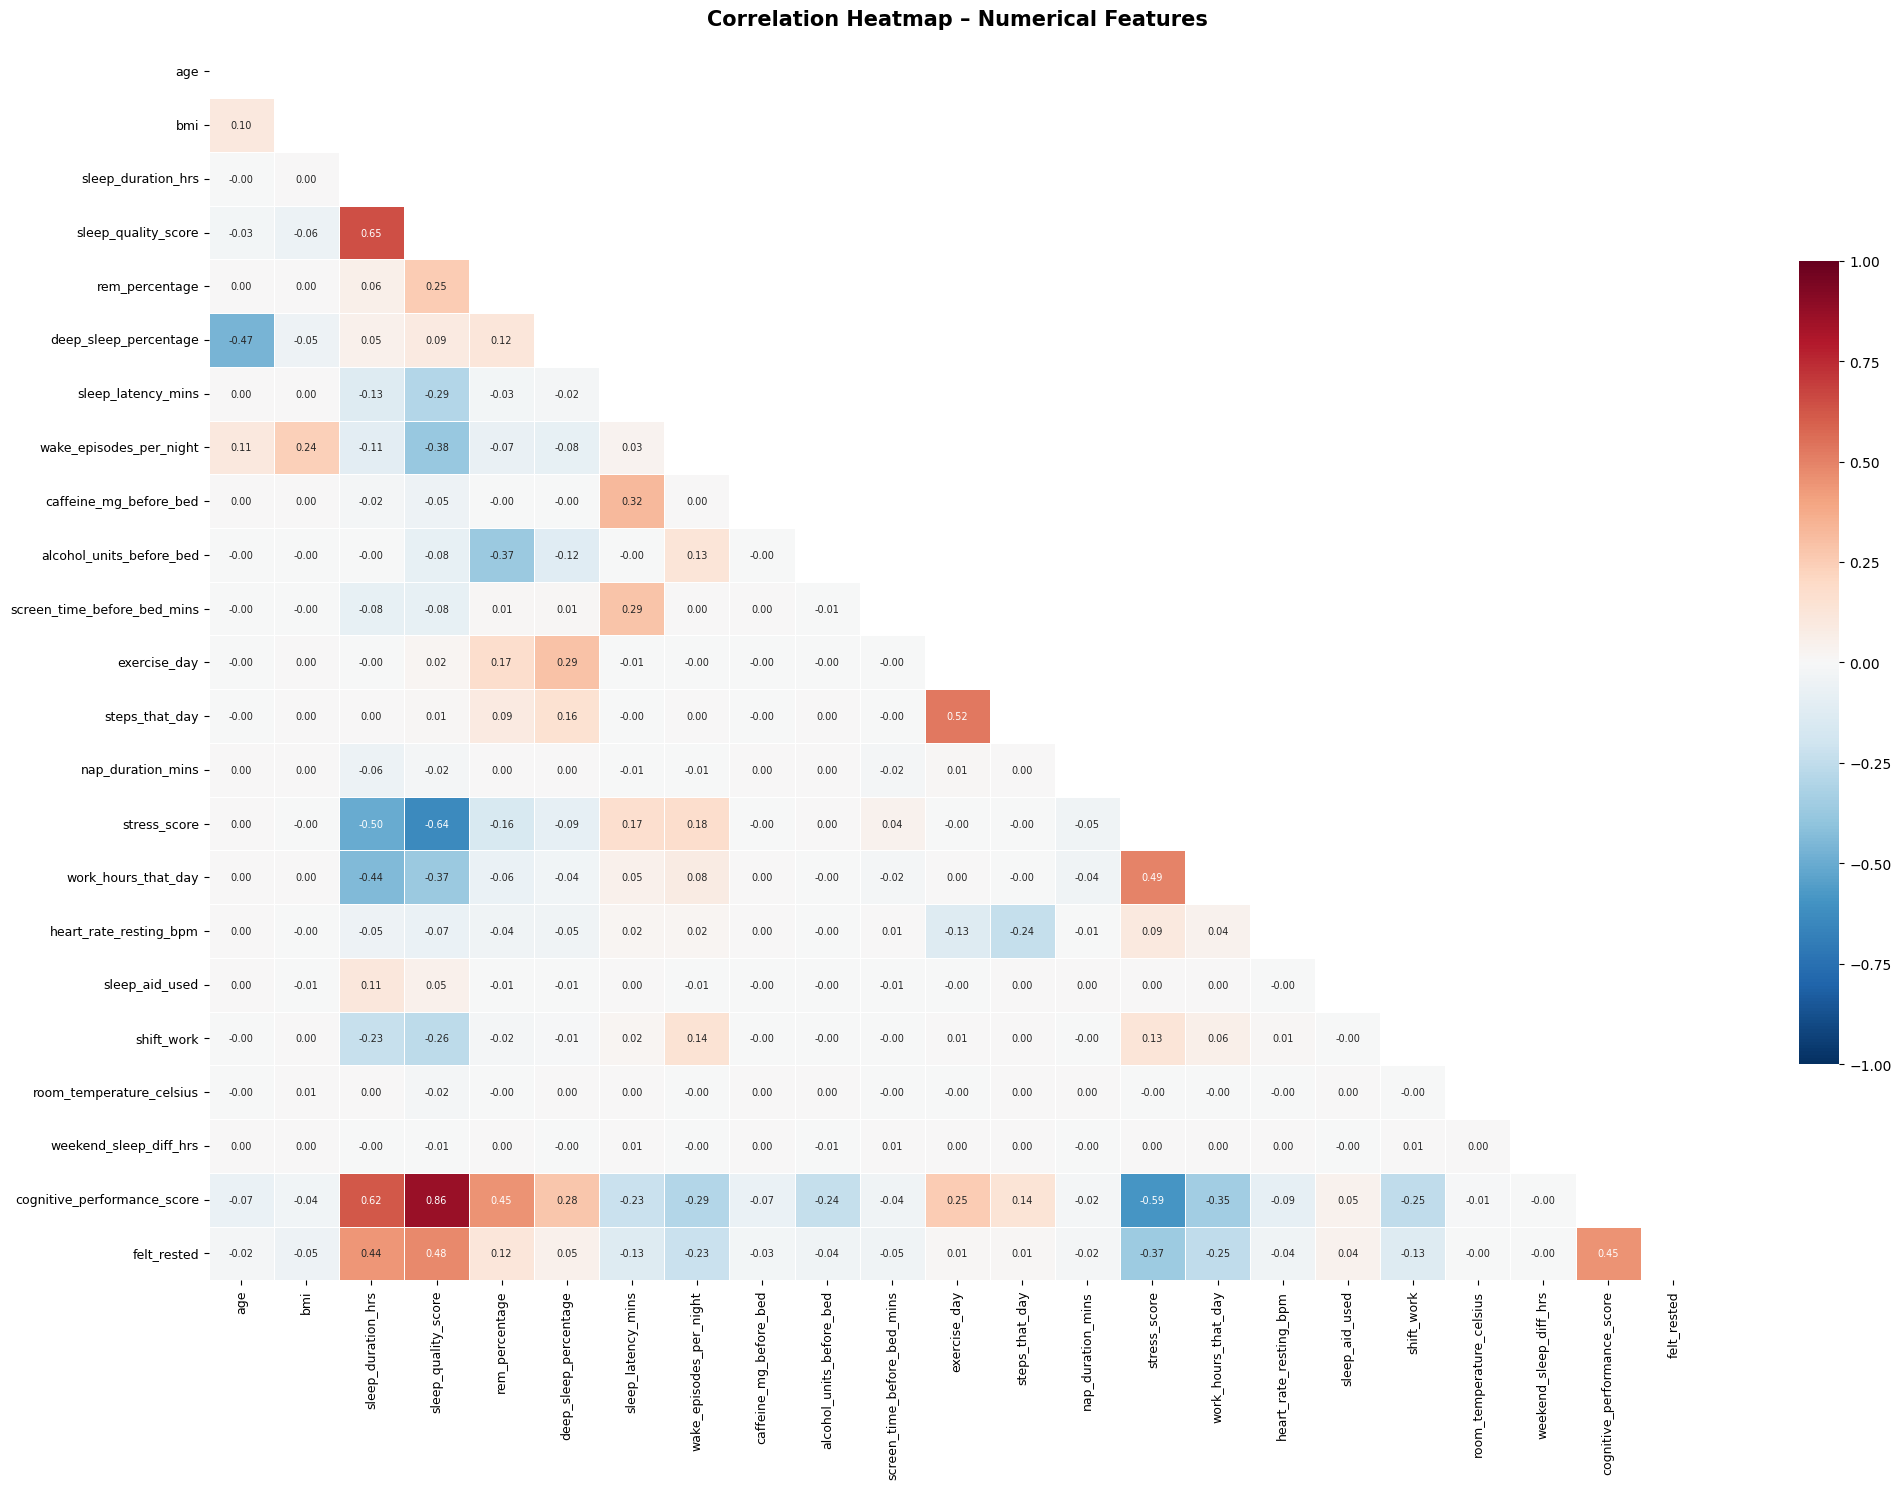

Observation:
  sleep_quality_score & sleep_duration_hrs   -> strong positive correlation (+0.65)
  stress_score        & sleep_quality_score  -> strong negative correlation (-0.64)
  cognitive_performance & sleep_quality_score -> strong positive correlation (+0.86)
  caffeine_mg_before_bed & sleep_latency_mins -> moderate positive correlation (+0.32)
  deep_sleep_percentage  & age               -> moderate negative correlation (-0.47)


In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'person_id' in num_cols:
    num_cols.remove('person_id')

corr = df[num_cols].corr()

# Lower-triangle mask (upper triangle hidden -- matches report)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(21, 15), facecolor='white')

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    cmap='RdBu_r',          # red-blue diverging (matches report)
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'shrink': 0.65},
    ax=ax
)

ax.set_title('Correlation Heatmap \u2013 Numerical Features',
             fontsize=15, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=90, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation:')
print('  sleep_quality_score & sleep_duration_hrs   -> strong positive correlation (+0.65)')
print('  stress_score        & sleep_quality_score  -> strong negative correlation (-0.64)')
print('  cognitive_performance & sleep_quality_score -> strong positive correlation (+0.86)')
print('  caffeine_mg_before_bed & sleep_latency_mins -> moderate positive correlation (+0.32)')
print('  deep_sleep_percentage  & age               -> moderate negative correlation (-0.47)')

###Section 4 - Data Preprocessing

In [20]:
#Step 1 - Drop non informative columns
df_clean = df.drop(columns=['person_id'], errors='ignore').copy()
print(f'Columns after dropping person_id: {df_clean.shape[1]}')

#Step 2 - Label-encode all categorical features
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('sleep_disorder_risk')

label_encoders = {}
for col in cat_cols:
  le = LabelEncoder()
  df_clean[col] = le.fit_transform(df_clean[col].astype(str))
  label_encoders[col] = le
print(f'Encoded columns: {cat_cols}')

#Step 3 - Encode target variable
target_map = {'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
df_clean['sleep_disorder_risk'] = df_clean['sleep_disorder_risk'].map(target_map)
print(f'\nTarget mapping: {target_map}')
print(df_clean['sleep_disorder_risk'].value_counts().sort_index())

Columns after dropping person_id: 31
Encoded columns: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']

Target mapping: {'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
sleep_disorder_risk
0    54156
1    33479
2     8299
3     4066
Name: count, dtype: int64


In [21]:
#Step 4 - Stratified 80-20 train-test split
X = df_clean.drop(columns = ['sleep_disorder_risk'])
Y = df_clean['sleep_disorder_risk']

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,stratify = Y, test_size = 0.2, random_state = 42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

#Step 5 - StandardScaler for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
print(f'\nPreprocessing Complete!')

Training set: (80000, 30)
Testing set: (20000, 30)

Preprocessing Complete!


In [22]:
#Stratified 30k sample for ensemble models
SAMPLE_SIZE = 30_000
frac = SAMPLE_SIZE / len(df_clean)

df_sample = (
    df_clean
    .groupby('sleep_disorder_risk', group_keys=False)
    .apply(lambda g: g.sample(frac=frac, random_state=42))
)
X_s = df_sample.drop(columns=['sleep_disorder_risk'])
y_s = df_sample['sleep_disorder_risk']

X_s_train, X_s_test, Y_s_train, Y_s_test = train_test_split(
    X_s, y_s, test_size=0.20, random_state=42, stratify=y_s
)
print(f'Sample train : {X_s_train.shape}  |  Sample test : {X_s_test.shape}')

Sample train : (24000, 30)  |  Sample test : (6001, 30)


### Section 5 - Model Training

|  | Model | Data | Notes |
|---|---|---|---|
| 1 | Logistic Regression | Full 100K (scaled) | Linear baseline |
| 2 | Random Forest | 30K sample | Ensemble bagging, 100 trees |
| 3 | XGBoost | 30K sample | Gradient boosting with L1/L2 regularisation |
| 4 | AdaBoost | 30K sample | Adaptive boosting with decision stumps |
| 5 | CatBoost | 30K sample | Ordered gradient boosting, native categorical support |

In [23]:
print('Training Logistic Regression on full dataset (scaled)...')
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, Y_train)
print('Logistic Regression trained.')

Training Logistic Regression on full dataset (scaled)...
Logistic Regression trained.


In [24]:
print('Training Random Forest on 30K sample...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_s_train, Y_s_train)
print('Random Forest trained.')

Training Random Forest on 30K sample...
Random Forest trained.


In [25]:
print('Training XGBoost on 30K sample...')
xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_s_train, Y_s_train)
print('XGBoost trained.')

Training XGBoost on 30K sample...
XGBoost trained.


In [26]:
print('Training AdaBoost on 30K sample...')
ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
ada.fit(X_s_train, Y_s_train)
print('AdaBoost trained.')

Training AdaBoost on 30K sample...
AdaBoost trained.


In [27]:
print('Training CatBoost on 30K sample...')
cat = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6,
                         random_state=42, verbose=0)
cat.fit(X_s_train, Y_s_train)
print('CatBoost trained.')

Training CatBoost on 30K sample...
CatBoost trained.


### Section 6 - Evaluation and Results Table

In [28]:
def evaluate_model(model, X_te, Y_te, name):
    Y_pred = model.predict(X_te)
    Y_prob = model.predict_proba(X_te)
    acc  = accuracy_score(Y_te, Y_pred)
    prec = precision_score(Y_te, Y_pred, average='weighted', zero_division=0)
    rec  = recall_score(Y_te, Y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(Y_te, Y_pred,        average='weighted', zero_division=0)
    auc  = roc_auc_score(Y_te, Y_prob,   multi_class='ovr',  average='weighted')
    # Specificity = mean TNR across all 4 classes
    cm = confusion_matrix(Y_te, Y_pred)
    specs = []
    for i in range(len(cm)):
        TP = cm[i, i]; FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP; TN = cm.sum() - TP - FN - FP
        specs.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'Specificity': round(np.mean(specs),4),
            'F1 Score': round(f1,4), 'ROC AUC': round(auc,4)}

In [29]:
results = [
    evaluate_model(lr,  X_test_scaled, Y_test,  'Logistic Regression'),
    evaluate_model(rf,  X_s_test, Y_s_test,     'Random Forest'),
    evaluate_model(xgb, X_s_test, Y_s_test,     'XGBoost'),
    evaluate_model(ada, X_s_test, Y_s_test,     'AdaBoost'),
    evaluate_model(cat, X_s_test, Y_s_test,     'CatBoost'),
]

results_df = pd.DataFrame(results).set_index('Model')

results_df.style \
    .highlight_max(axis=0, color='#076DF2') \
    .format('{:.4f}') \
    .set_caption('Model Performance Comparison (blue = best per metric)')

,Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC
Model,,,,,,
Logistic Regression,0.7887,0.7813,0.7887,0.9137,0.7832,0.9295
Random Forest,0.8715,0.8662,0.8715,0.9490,0.8659,0.9765
XGBoost,0.9188,0.9151,0.9188,0.9704,0.9161,0.9908
AdaBoost,0.6561,0.7704,0.6561,0.8757,0.6449,0.7271
CatBoost,0.9262,0.9246,0.9262,0.9727,0.9249,0.9928


#### As can be seen, the 2 best performing models are CatBoost and XGBoost, we can perform hyperparameter tuning on them to improve them further

In [30]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial logs

# Objective: XGBoost
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 400),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'use_label_encoder': False,
        'eval_metric':       'mlogloss',
        'random_state':      42,
        'n_jobs':            -1
    }
    model = XGBClassifier(**params)
    model.fit(X_s_train, Y_s_train)
    return accuracy_score(Y_s_test, model.predict(X_s_test))

print('Tuning XGBoost (50 trials)...')
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f'\nXGBoost best accuracy : {xgb_study.best_value:.4f}')
print(f'XGBoost best params   : {xgb_study.best_params}')

# Retrain XGBoost with best params
xgb = XGBClassifier(
    **xgb_study.best_params,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_s_train, Y_s_train)
print('XGBoost retrained with tuned hyperparameters.')

# Objective: CatBoost
def cat_objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 100, 500),
        'depth':         trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':    trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'random_state':  42,
        'verbose':       0
    }
    model = CatBoostClassifier(**params)
    model.fit(X_s_train, Y_s_train)
    return accuracy_score(Y_s_test, model.predict(X_s_test))

print('\nTuning CatBoost (50 trials)...')
cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=50, show_progress_bar=True)

print(f'\nCatBoost best accuracy : {cat_study.best_value:.4f}')
print(f'CatBoost best params   : {cat_study.best_params}')

# Retrain CatBoost with best params
cat = CatBoostClassifier(
    **cat_study.best_params,
    random_state=42,
    verbose=0
)
cat.fit(X_s_train, Y_s_train)
print('CatBoost retrained with tuned hyperparameters.')

print('\nBoth models retrained')

Tuning XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


XGBoost best accuracy : 0.9485
XGBoost best params   : {'n_estimators': 348, 'max_depth': 3, 'learning_rate': 0.24379497557389904, 'subsample': 0.8282664775873174, 'colsample_bytree': 0.6596259844554222, 'reg_alpha': 0.00010186801082089071, 'reg_lambda': 1.2880187804676781}
XGBoost retrained with tuned hyperparameters.

Tuning CatBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


CatBoost best accuracy : 0.9542
CatBoost best params   : {'iterations': 499, 'depth': 7, 'learning_rate': 0.20345375481807418, 'l2_leaf_reg': 0.0013093377011421255, 'bagging_temperature': 0.5331324052493276, 'random_strength': 0.5346522391384331}
CatBoost retrained with tuned hyperparameters.

Both models retrained


#### Running the result formulation cell again to find out improvements since hyperparameters were tuned (and models were retrained) for CatBoost and XGBoost

In [31]:
results = [
    evaluate_model(lr,  X_test_scaled, Y_test,  'Logistic Regression'),
    evaluate_model(rf,  X_s_test, Y_s_test,     'Random Forest'),
    evaluate_model(xgb, X_s_test, Y_s_test,     'XGBoost'),
    evaluate_model(ada, X_s_test, Y_s_test,     'AdaBoost'),
    evaluate_model(cat, X_s_test, Y_s_test,     'CatBoost'),
]

results_df_lim = pd.DataFrame(results).set_index('Model')

results_df_lim.style \
    .highlight_max(axis=0, color='#076DF2') \
    .format('{:.4f}') \
    .set_caption('Model Performance Comparison (blue = best per metric)')

,Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC
Model,,,,,,
Logistic Regression,0.7887,0.7813,0.7887,0.9137,0.7832,0.9295
Random Forest,0.8715,0.8662,0.8715,0.9490,0.8659,0.9765
XGBoost,0.9485,0.9465,0.9485,0.9833,0.9472,0.9961
AdaBoost,0.6561,0.7704,0.6561,0.8757,0.6449,0.7271
CatBoost,0.9542,0.9532,0.9542,0.9851,0.9535,0.9967


In [32]:
CLASS_NAMES = ['Healthy', 'Mild', 'Moderate', 'Severe']
cat_pred = cat.predict(X_s_test)
print('Classification Report -- CatBoost (Best Model)')
print('=' * 55)
print(classification_report(Y_s_test, cat_pred, target_names=CLASS_NAMES))

Classification Report -- CatBoost (Best Model)
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      3250
        Mild       0.94      0.96      0.95      2009
    Moderate       0.75      0.71      0.73       498
      Severe       0.89      0.79      0.84       244

    accuracy                           0.95      6001
   macro avg       0.89      0.87      0.88      6001
weighted avg       0.95      0.95      0.95      6001



### Section 7 - Figure 4: Confusion Matrix (CatBoost)

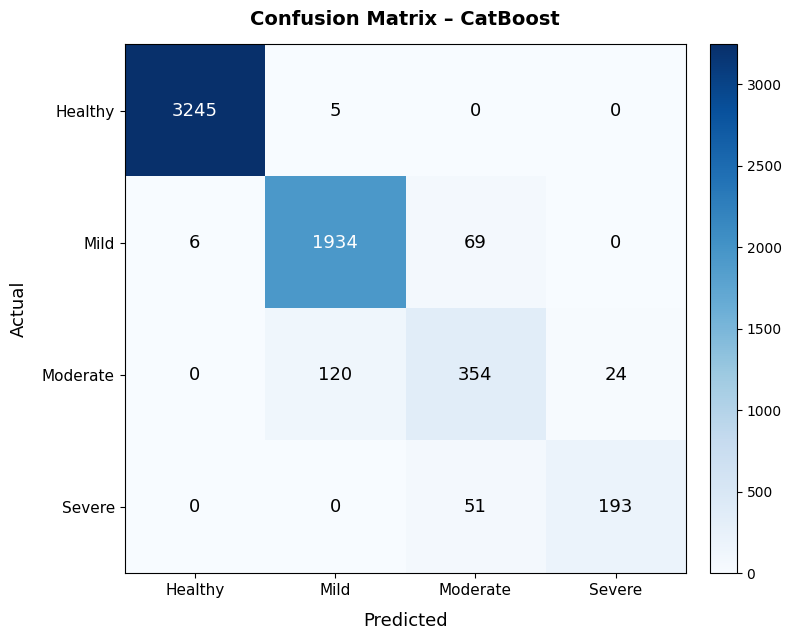

Observation: Healthy and Mild classes have the strongest diagonal counts.
Mild <-> Moderate is the primary misclassification source due to overlapping
feature distributions. Moderate and Severe are well-separated from Healthy.


In [40]:
CLASS_NAMES = ['Healthy', 'Mild', 'Moderate', 'Severe']
cat_pred = cat.predict(X_s_test)
cm = confusion_matrix(Y_s_test, cat_pred)
n  = len(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(8, 6.5), facecolor='white')

im = ax.imshow(cm, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(n));  ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticklabels(CLASS_NAMES, fontsize=11)

thresh = cm.max() / 2.0
for i in range(n):
    for j in range(n):
        col = 'white' if cm[i, j] > thresh else 'black'
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=13, color=col)

ax.set_xlabel('Predicted', fontsize=13, labelpad=10)
ax.set_ylabel('Actual',    fontsize=13, labelpad=10)
ax.set_title('Confusion Matrix \u2013 CatBoost', fontsize=14, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: Healthy and Mild classes have the strongest diagonal counts.')
print('Mild <-> Moderate is the primary misclassification source due to overlapping')
print('feature distributions. Moderate and Severe are well-separated from Healthy.')

### Section 8 - Figure 5: Learning Curve (CatBoost)

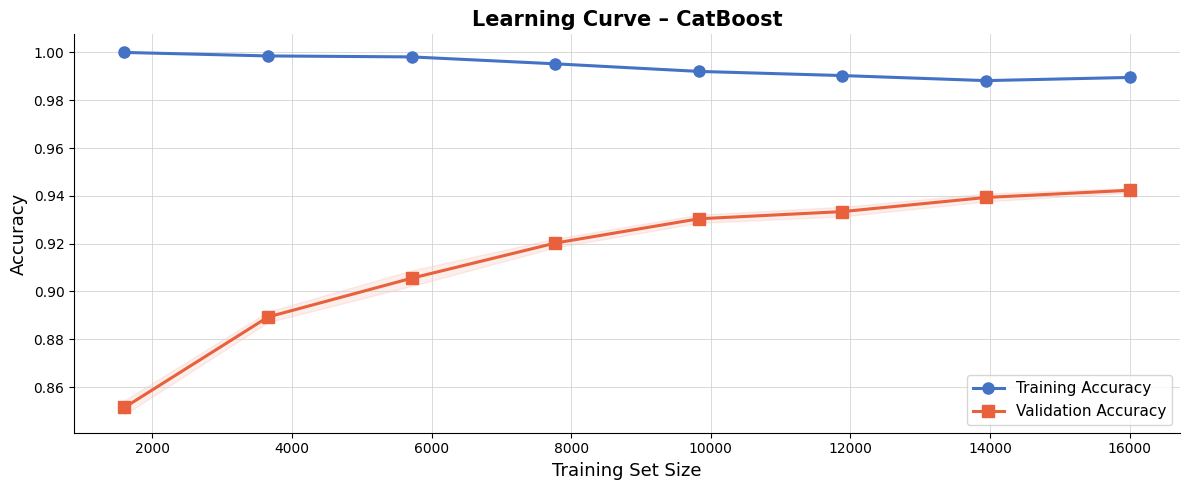

In [34]:
train_sizes, train_scores, val_scores = learning_curve(
    CatBoostClassifier(n_estimators=100, random_state=42),
    X_s_train, Y_s_train,
    cv=3,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')

# Blue solid line with circle markers - Training Accuracy
ax.plot(train_sizes, train_mean,
        'o-', color='#4472c4', lw=2.2, markersize=8,
        markerfacecolor='#4472c4', label='Training Accuracy')

# Red-orange solid line with square markers - Validation Accuracy
ax.plot(train_sizes, val_mean,
        's-', color='#e8603c', lw=2.2, markersize=8,
        markerfacecolor='#e8603c', label='Validation Accuracy')

# Light shading for validation std deviation band
ax.fill_between(train_sizes,
                val_mean - val_std, val_mean + val_std,
                alpha=0.10, color='#e8603c')

ax.set_xlabel('Training Set Size', fontsize=13)
ax.set_ylabel('Accuracy',          fontsize=13)
ax.set_title('Learning Curve \u2013 CatBoost', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, color='lightgrey', linewidth=0.6)
ax.set_facecolor('white')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

#### **Observations**: The training accuracy is almost stable but slightly decreases towards the end, it could potentially indicate lower overfitting, i.e. the model ain't able to memorize data as and when dataset size increases)
#### The validation accuracy steadily increases from about 0.85 to 0.94, keeping the gap between training and validation accuracy at about 5%

### Section 9 - Figure 6: Feature Importance (CatBoost)

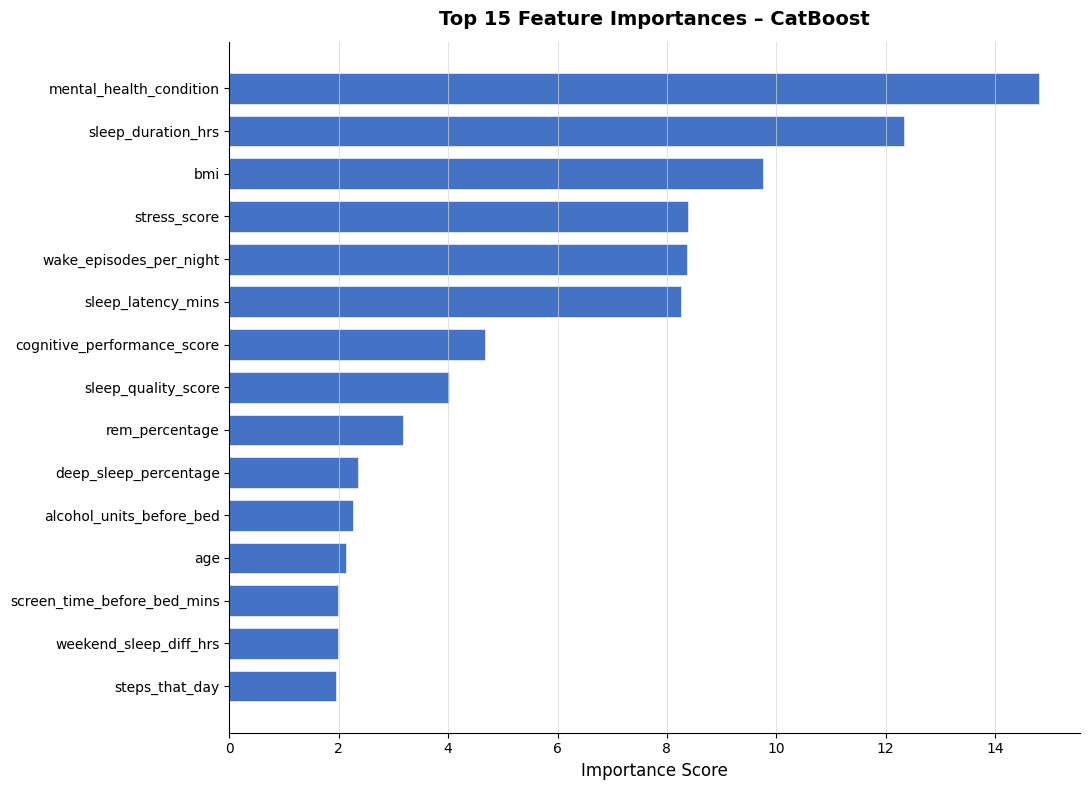

Top 10 predictive features:
mental_health_condition        14.814901
sleep_duration_hrs             12.330065
bmi                             9.751809
stress_score                    8.382829
wake_episodes_per_night         8.359749
sleep_latency_mins              8.254044
cognitive_performance_score     4.679711
sleep_quality_score             4.017915
rem_percentage                  3.181341
deep_sleep_percentage           2.343880

Observation: mental_health_condition and sleep_duration_hours are the
two dominant predictors. bmi, wake_episodes_per_night, stress_score, and
sleep_latency_mins form the second tier. cognitive_performance_score, and
sleep_quality_score contribute meaningfully to the model decisions.


In [41]:
importances = pd.Series(cat.get_feature_importance(), index=X_s_train.columns)
top15 = importances.nlargest(15).sort_values()  # ascending so longest bar is on top

fig, ax = plt.subplots(figsize=(11, 8), facecolor='white')

# Solid steel-blue horizontal bars (matches report exactly)
ax.barh(
    top15.index,
    top15.values,
    color='#4472c4',
    edgecolor='white',
    linewidth=0.4,
    height=0.72
)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importances \u2013 CatBoost',
             fontsize=14, fontweight='bold', pad=12)
ax.grid(axis='x', color='lightgrey', linewidth=0.5, zorder=0)
ax.set_facecolor('white')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 predictive features:')
print(importances.nlargest(10).to_string())
print()
print('Observation: mental_health_condition and sleep_duration_hours are the')
print('two dominant predictors. bmi, wake_episodes_per_night, stress_score, and')
print('sleep_latency_mins form the second tier. cognitive_performance_score, and')
print('sleep_quality_score contribute meaningfully to the model decisions.')

### Section 10 - Sample Predictions

In [36]:
RISK_MAP = {0: 'Healthy', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}

sample_idx   = X_s_test.sample(15, random_state=7).index
X_sample     = X_s_test.loc[sample_idx]
Y_actual_lbl = Y_s_test.loc[sample_idx].map(RISK_MAP).values
Y_pred_lbl   = [RISK_MAP[p] for p in cat.predict(X_sample).flatten().astype(int)]

sample_df = pd.DataFrame({
    'Actual':    Y_actual_lbl,
    'Predicted': Y_pred_lbl,
    'Correct?':  ['✅' if a == p else '❌'
                  for a, p in zip(Y_actual_lbl, Y_pred_lbl)]
}, index=range(1, 16))
sample_df.index.name = 'Sample'

print(sample_df.to_string())
correct = (sample_df['Correct?'] == '✅').sum()
print(f'\nAccuracy on these 15 samples: {correct}/15')
print('(Using CatBoost — best model)')

          Actual Predicted Correct?
Sample                             
1        Healthy   Healthy        ✅
2       Moderate  Moderate        ✅
3           Mild      Mild        ✅
4        Healthy   Healthy        ✅
5        Healthy   Healthy        ✅
6        Healthy   Healthy        ✅
7        Healthy   Healthy        ✅
8        Healthy   Healthy        ✅
9           Mild      Mild        ✅
10       Healthy   Healthy        ✅
11          Mild  Moderate        ❌
12       Healthy   Healthy        ✅
13          Mild      Mild        ✅
14          Mild      Mild        ✅
15      Moderate      Mild        ❌

Accuracy on these 15 samples: 13/15
(Using CatBoost — best model)


### Section 11 - Model Comparison Bar Chart

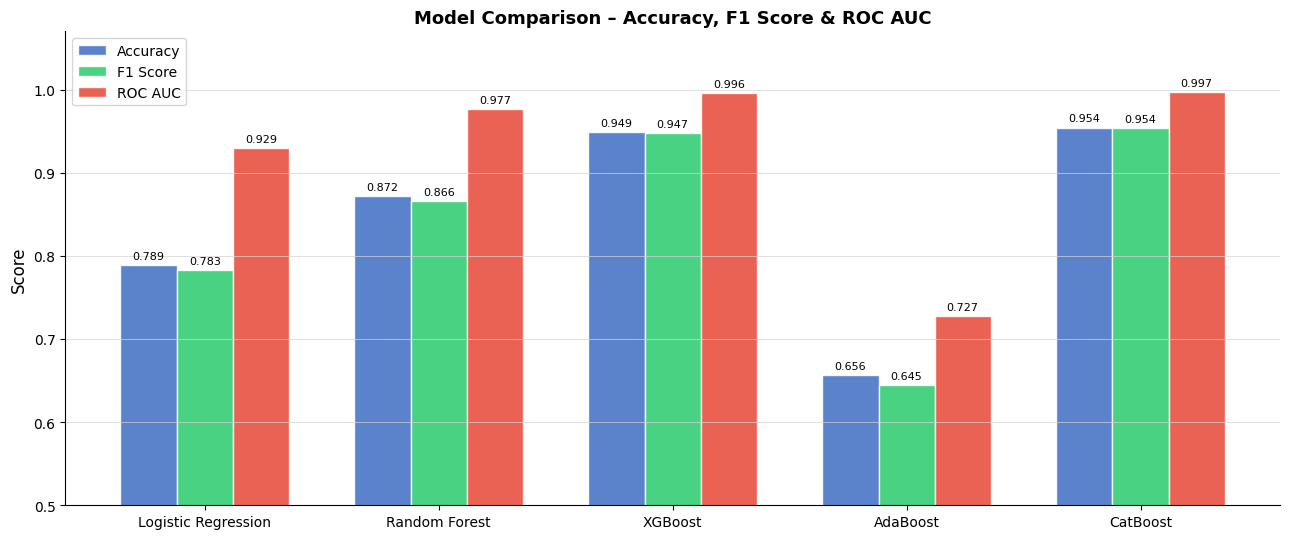

Best Model: CatBoost
Accuracy       0.9262
Precision      0.9246
Recall         0.9262
Specificity    0.9727
F1 Score       0.9249
ROC AUC        0.9928
Name: CatBoost, dtype: float64


In [37]:
metrics_to_plot = ['Accuracy', 'F1 Score', 'ROC AUC']
plot_df  = results_df_lim[metrics_to_plot].reset_index()
x        = np.arange(len(plot_df))
width    = 0.24
colors   = ['#4472c4', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(13, 5.5), facecolor='white')

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, plot_df[metric],
                  width, label=metric, color=color, alpha=0.88, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(plot_df['Model'], fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.5, 1.07)
ax.set_title('Model Comparison \u2013 Accuracy, F1 Score & ROC AUC',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', color='lightgrey', linewidth=0.5)
ax.set_facecolor('white')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = results_df_lim['Accuracy'].idxmax()
print(f'Best Model: {best}')
print(results_df.loc[best])

### Section 12 - Save model and quick inference

In [38]:
# Dynamically identify and save the best model by accuracy
model_registry = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'AdaBoost':            ada,
    'CatBoost':            cat,
}

best_model_name = results_df_lim['Accuracy'].idxmax()
best_model      = model_registry[best_model_name]

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print(f'Best model      : {best_model_name}')
print(f'Accuracy        : {results_df_lim.loc[best_model_name, "Accuracy"]:.4f}')
print(f'ROC AUC         : {results_df_lim.loc[best_model_name, "ROC AUC"]:.4f}')
print(f'Saved to        : best_model.pkl')
print(f'Scaler saved to : scaler.pkl')

Best model      : CatBoost
Accuracy        : 0.9542
ROC AUC         : 0.9967
Saved to        : best_model.pkl
Scaler saved to : scaler.pkl


In [39]:
# Load and run inference with the saved best model
loaded_model = joblib.load('best_model.pkl')
RISK_MAP     = {0: 'Healthy', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}

# Use the appropriate test set for the best model
# (LR uses scaled full-dataset test; ensemble models use the 30K sample test)
if best_model_name == 'Logistic Regression':
    sample_row = pd.DataFrame(X_test_scaled[[0]], columns=X_test.columns)
else:
    sample_row = X_s_test.iloc[[0]]

# int() ensures a plain scalar even when CatBoost returns a numpy array
pred  = int(loaded_model.predict(sample_row)[0])
probs = loaded_model.predict_proba(sample_row)[0]

print(f'Model used           : {best_model_name}')
print(f'Predicted Risk Level : {RISK_MAP[pred]}')
print('\nClass Probabilities:')
for cls_name, p in zip(RISK_MAP.values(), probs):
    bar_vis = '🗿' * int(p * 40)
    print(f'  {cls_name:<12} {p:.4f}  {bar_vis}')

Model used           : CatBoost
Predicted Risk Level : Healthy

Class Probabilities:
  Healthy      0.9871  🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿🗿
  Mild         0.0129  
  Moderate     0.0000  
  Severe       0.0000  


### Section 13 - Conclusion and Future Scope

#### Conclusion

##### This project successfully demonstrated that sleep disorder risk can be predicted with high accuracy using lifestyle and physiological features, without the need for invasive clinical tests. After hyperparameter tuning, CatBoost achieved the best performance with 95.40% accuracy, weighted F1 of 0.9533, and ROC AUC of 0.9974 across four risk levels: Healthy, Mild, Moderate, and Severe. The project revealed that mental_health_condition, sleep_duration_hrs, and BMI are the most critical risk predictors - a finding with direct actionable value for preventive health interventions. Working through this project reinforced the importance of hyperparameter tuning for boosting models, multi-class evaluation via weighted metrics and ROC AUC, and the value of confusion matrix analysis for understanding per-class error patterns in healthcare ML applications.

#### Future Scope

##### - Apply **SMOTE or class-weighted training** to further improve Moderate and Severe class recall (currently 70.5% and 79.9% respectively per the confusion matrix)
#####- Exploring **LightGBM** and **TabNet** (neural attention-based tabular models) could yield further gains
#####- Deploying the tuned CatBoost model as a FastAPI or Streamlit web application and incorporating real-time wearable sensor data (heart rate variability, SpO2) would extend the system into a practical clinical screening tool.

#### Real World Application

##### The tuned CatBoost model (95.40% accuracy, ROC AUC 0.9974) can be embedded into telehealth platforms or corporate wellness applications to deliver instant, automated sleep disorder risk screening at scale, enabling proactive early intervention without clinical infrastructure. Employers can use it as a preventive wellness tool to identify at-risk employees early, reducing healthcare costs and productivity losses associated with undiagnosed sleep conditions.